In [1]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Step 2: Import Required Libraries
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
# Step 3: Define Dataset Paths (Update Path to Match Your Google Drive Folder)
base_path = "/content/drive/My Drive/Colab Notebooks/Project"  # Change if necessary

train_dir = os.path.join(base_path, "train")
vali_dir = os.path.join(base_path, "validation")
test_dir = os.path.join(base_path, "test")

In [4]:
# Step 4: Ensure Folder Names Are Valid (Remove Spaces)
def rename_folders(directory):
    for folder in os.listdir(directory):
        old_path = os.path.join(directory, folder)
        new_folder = folder.replace(" ", "_")  # Replace spaces with underscores
        new_path = os.path.join(directory, new_folder)
        if os.path.isdir(old_path) and old_path != new_path:
            os.rename(old_path, new_path)

rename_folders(train_dir)
rename_folders(vali_dir)
rename_folders(test_dir)

In [5]:
# Step 5: Load Dataset
batch_size = 32
img_size = (300, 500)

# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

# Load Training Dataset (Without Augmentation First)
train_dataset_raw = image_dataset_from_directory(
    directory=train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# Retrieve Class Names Before Applying Augmentation
class_names = train_dataset_raw.class_names  # Get class names before mapping
num_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", num_classes)

# Apply Data Augmentation
train_dataset = train_dataset_raw.map(lambda x, y: (data_augmentation(x, training=True), y))

# Load Validation and Test Datasets (without augmentation)
validation_dataset = image_dataset_from_directory(
    directory=vali_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_dataset = image_dataset_from_directory(
    directory=test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,  # No shuffling for test set
    label_mode='categorical'
)


Found 4820 files belonging to 7 classes.
Class names: ['Category1__Hairline_Cracks', 'Category2_Small_Cracks', 'Category3_Moderate_Cracks', 'Category4_Large_Cracks', 'Category5_Very_Large_Cracks', 'Category6_No_Cracks', 'Category7__Concrete_Corrosion_Cracks']
Number of classes: 7
Found 1049 files belonging to 7 classes.
Found 1047 files belonging to 7 classes.


In [6]:
# Step 6: Define CNN Model
from tensorflow.keras import layers, models, optimizers, callbacks

def build_model():
    inputs = tf.keras.Input(shape=(300, 500, 3))
    x = layers.Rescaling(1./255)(inputs)
    x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss="categorical_crossentropy",
        optimizer=optimizers.Adam(learning_rate=1e-4),
        metrics=['accuracy']
    )
    return model

In [7]:
# Step 7a: Train Model with Early Stopping
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,  # Stop training if val_accuracy does not improve for 3 consecutive epochs
    restore_best_weights=True
)

model = build_model()
model.summary()

epochs =50 # Increase for better accuracy
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stopping]  # With Early Stopping
)

# Step 7b: Train Model without Early Stopping
model_no_es = build_model()
history_no_es = model_no_es.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 300, 500, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 300, 500, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 298, 498, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 149, 249, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 147, 247, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 73, 123, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 121, 128)        │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 35, 60, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 33, 58, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 29, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 118784)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      15,204,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,593,799 (59.49 MB)

 Trainable params: 15,593,799 (59.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.2568 - loss: 1.8034 - val_accuracy: 0.4919 - val_loss: 1.2900
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.4893 - loss: 1.2146 - val_accuracy: 0.5062 - val_loss: 1.2846
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.5222 - loss: 1.1553 - val_accuracy: 0.5367 - val_loss: 1.0806
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.5561 - loss: 1.0518 - val_accuracy: 0.5710 - val_loss: 0.9740
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.5999 - loss: 0.9675 - val_accuracy: 0.6473 - val_loss: 0.9106
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.6268 - loss: 0.9009 - val_accuracy: 0.6749 - val_loss: 0.7512
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.6537 - loss: 0.8291 - val_accuracy: 0.6654 - val_loss: 0.7774
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.6579 - loss: 0.8036 - val_accu

In [8]:
# Step 8: Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)


33/33 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.6154 - loss: 0.8296
Test Accuracy: 0.6638013124465942


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

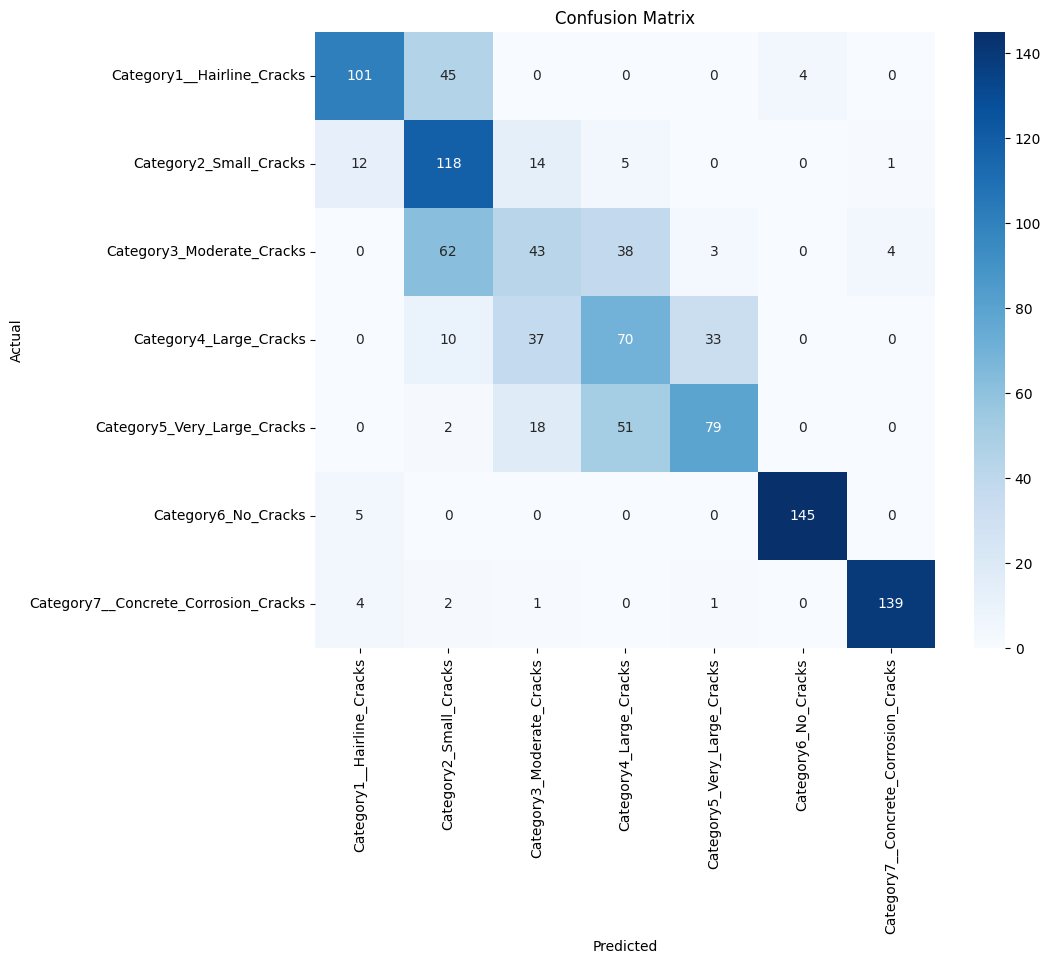

In [9]:
# Step 9: Generate Confusion Matrix
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


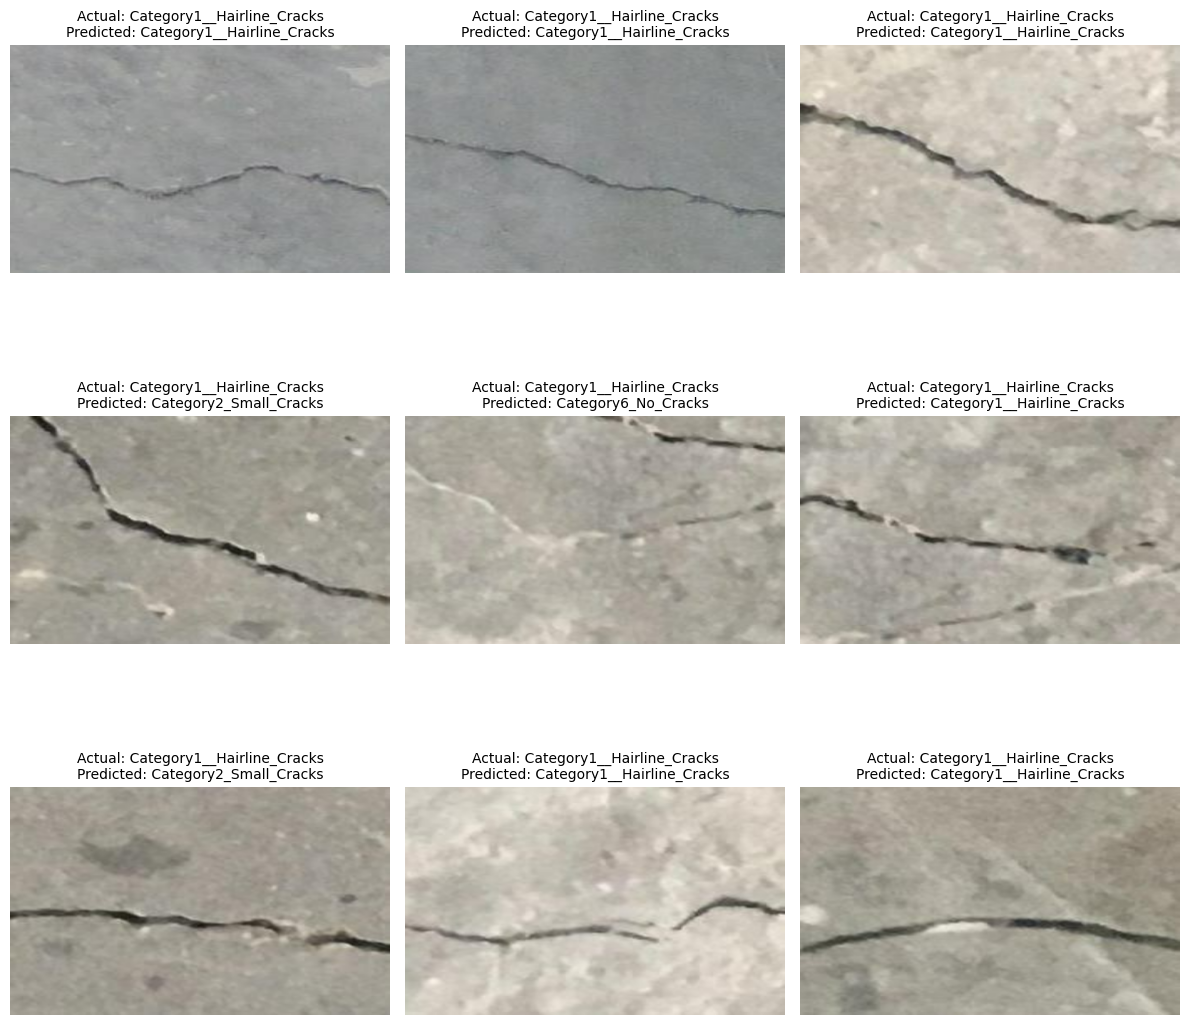

In [10]:
# Step 10: Display Test Images with Predictions
def display_test_predictions(model, dataset, class_names):
    plt.figure(figsize=(12, 12))
    images, labels = next(iter(dataset))  # Get a batch of test images
    predictions = model.predict(images)

    for i in range(9):  # Display 9 images
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        actual_label = class_names[np.argmax(labels[i])]
        predicted_label = class_names[np.argmax(predictions[i])]
        plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the function
display_test_predictions(model, test_dataset, class_names)

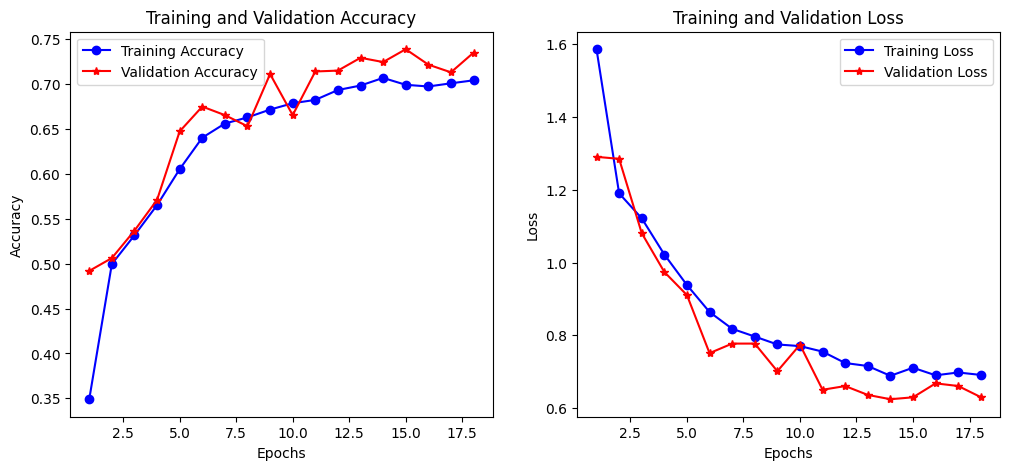

In [11]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Plots the training and validation accuracy and loss over epochs.
    """
    # Extract accuracy and loss values
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Plot Accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

# Call function after training
plot_training_history(history)


In [12]:
# Step 10: Print Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))



Classification Report:
                                       precision    recall  f1-score   support

          Category1__Hairline_Cracks       0.83      0.67      0.74       150
              Category2_Small_Cracks       0.49      0.79      0.61       150
           Category3_Moderate_Cracks       0.38      0.29      0.33       150
              Category4_Large_Cracks       0.43      0.47      0.45       150
         Category5_Very_Large_Cracks       0.68      0.53      0.59       150
                 Category6_No_Cracks       0.97      0.97      0.97       150
Category7__Concrete_Corrosion_Cracks       0.97      0.95      0.96       147

                            accuracy                           0.66      1047
                           macro avg       0.68      0.66      0.66      1047
                        weighted avg       0.68      0.66      0.66      1047

